# Multi-array ancestry-specific Multidimensional Scaling (maasMDS)

maasMDS is designed for multi-array genotype data. Different arrays share some SNPs, but each array also has array-specific content. If we ignore that structure, individuals tend to cluster by array. maasMDS uses pairwise SNP overlaps to calibrate distances.

## Simulate three genotyping arrays

The synthetic dataset has three arrays, each with 200 individuals and 1,000 SNPs. Each pair of arrays shares 450 SNPs, and all three arrays share 250 SNPs. The rest are array-specific.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import MDS as SklearnMDS

from snputils import maasMDS
from snputils.datasets import build_synthetic_maasmds_dataset

RESULTS_DIR = Path("results/tutorials/maasmds")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SEED = 20240520

dataset = build_synthetic_maasmds_dataset(
    n_samples_per_array=200,
    n_snps_per_array=1_000,
    seed=SEED,
)
snpobjs = dataset["snpobjs"]
laiobjs = dataset["laiobjs"]
labels = dataset["labels"]

print([snpobj.shape for snpobj in snpobjs])
pd.Series(dataset["overlap_counts"], name="n_snps").rename_axis("intersection").reset_index()

[(1000, 200, 2), (1000, 200, 2), (1000, 200, 2)]


,intersection,n_snps
0,array_1,1000
1,array_2,1000
2,array_3,1000
3,array_1_2,450
4,array_1_3,450
5,array_2_3,450
6,array_1_2_3,250


## A naive uncalibrated analysis clusters by array

This deliberately ignores the multi-array problem: it builds a union-SNP matrix, leaves absent array SNPs as a fixed no-call value, and runs ordinary PCA. The leading axes mostly describe which array a person came from, not their population label.

In [2]:
def array_dosage_matrix(snp):
    gt = snp.genotypes
    dosage = gt.sum(axis=2).astype(float)
    dosage[np.any(gt < 0, axis=2)] = np.nan
    return dosage.T

all_positions = sorted(set().union(*[set(snp.variants_pos.tolist()) for snp in snpobjs]))
position_index = {pos: idx for idx, pos in enumerate(all_positions)}

blocks = []
naive_labels = []
for array_id, snp in enumerate(snpobjs, start=1):
    dosage = array_dosage_matrix(snp)
    block = np.zeros((snp.n_samples, len(all_positions)), dtype=float)
    for local_idx, pos in enumerate(snp.variants_pos.tolist()):
        block[:, position_index[pos]] = np.nan_to_num(dosage[:, local_idx], nan=0.0)
    blocks.append(block)
    naive_labels.append(labels.loc[labels["array"] == array_id].copy())

X_naive = np.vstack(blocks)
naive_df = pd.concat(naive_labels, ignore_index=True)
naive_coords = SklearnPCA(n_components=2, random_state=SEED).fit_transform(X_naive)
naive_df["PC1"] = naive_coords[:, 0]
naive_df["PC2"] = naive_coords[:, 1]

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Naive union-SNP PCA: array effects dominate'}, xlabel='PC1', ylabel='PC2'>)

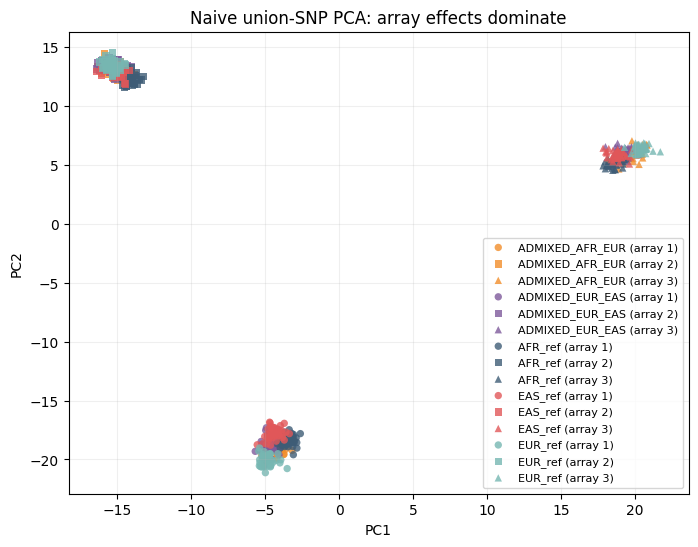

In [3]:
from snputils.visualization.constants import build_palette_mapping

def plot_population_by_array(df, x="PC1", y="PC2", title=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = build_palette_mapping(["AFR_ref", "EUR_ref", "EAS_ref", "ADMIXED_AFR_EUR", "ADMIXED_EUR_EAS"])
    markers = {1: "o", 2: "s", 3: "^"}
    for (label, array_id), sub in df.groupby(["label", "array"]):
        ax.scatter(
            sub[x],
            sub[y],
            c=colors[label],
            marker=markers[int(array_id)],
            s=28,
            alpha=0.8,
            edgecolors="none",
            label=f"{label} (array {array_id})",
        )

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc="best")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.2)
    return fig, ax

plot_population_by_array(naive_df, title="Naive union-SNP PCA: array effects dominate")

We compare three analyses on the same synthetic data:

1. **Uncalibrated ancestry-specific baseline**: mask to AFR and use only SNPs shared by all arrays (no multi-array calibration).
2. **Calibrated no-masking**: maasMDS with `is_masked=False`.
3. **Full maasMDS**: calibrated + AFR masking (`is_masked=True`, `ancestry='AFR'`).


In [4]:
def build_embedding_df(model, labels_df, xname, yname):
    emb = pd.DataFrame({
        "indID": model.samples_,
        "array": model.array_labels_,
        xname: model.X_new_[:, 0],
        yname: model.X_new_[:, 1],
    })
    return emb.merge(labels_df, on=["indID", "array"], how="left")

# Uncalibrated ancestry-specific baseline: AFR-masked dosages on SNPs shared by all arrays.
common_pos = set(snpobjs[0].variants_pos.tolist())
for snp in snpobjs[1:]:
    common_pos &= set(snp.variants_pos.tolist())
common_pos = sorted(common_pos)

ancestry_names = list(dataset["ancestry_map"].values())
afr_code = ancestry_names.index("AFR")

X_blocks = []
uncalibrated_labels = []
for array_id, (snp, lai) in enumerate(zip(snpobjs, laiobjs), start=1):
    pos_to_idx = {int(p): i for i, p in enumerate(snp.variants_pos.tolist())}
    keep_idx = np.asarray([pos_to_idx[int(p)] for p in common_pos], dtype=int)

    gt = snp.genotypes[keep_idx]  # (n_snps_common, n_samples, 2)
    lai_sub = lai.lai[keep_idx]   # (n_snps_common, n_samples*2)

    # haplotype-level mask from LAI ancestry code, then average strands
    afr_mask = lai_sub.reshape(len(common_pos), snp.n_samples, 2) == afr_code
    masked = gt.astype(float).copy()
    masked[~afr_mask] = np.nan
    masked[gt < 0] = np.nan

    dosage = np.nanmean(masked, axis=2).T  # (n_samples, n_snps_common)
    col_means = np.nanmean(dosage, axis=0)
    col_means = np.where(np.isfinite(col_means), col_means, 0.0)
    miss = np.isnan(dosage)
    if np.any(miss):
        dosage[miss] = np.take(col_means, np.where(miss)[1])

    X_blocks.append(dosage)
    uncalibrated_labels.append(labels.loc[labels["array"] == array_id].copy())

X_uncal = np.vstack(X_blocks)
uncalibrated_df = pd.concat(uncalibrated_labels, ignore_index=True)
uncal_coords = SklearnMDS(n_components=2, dissimilarity="euclidean", random_state=SEED).fit_transform(X_uncal)
uncalibrated_df["MDS1"] = uncal_coords[:, 0]
uncalibrated_df["MDS2"] = uncal_coords[:, 1]

mds_calibrated_no_mask = maasMDS(
    snpobj=snpobjs,
    laiobj=laiobjs,
    labels=labels,
    ancestry="AFR",
    is_masked=False,
    average_strands=True,
    min_percent_snps=1,
    group_snp_frequencies_only=False,
    distance_type="AP",
    n_components=2,
)
calibrated_no_mask_df = build_embedding_df(mds_calibrated_no_mask, labels, "MDS1", "MDS2")

mds_full = maasMDS(
    snpobj=snpobjs,
    laiobj=laiobjs,
    labels=labels,
    ancestry="AFR",
    is_masked=True,
    average_strands=True,
    min_percent_snps=1,
    group_snp_frequencies_only=False,
    distance_type="AP",
    n_components=2,
)
calibrated_df = build_embedding_df(mds_full, labels, "MDS1", "MDS2")

/private/home/dbonet/git/snputils/.venv/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


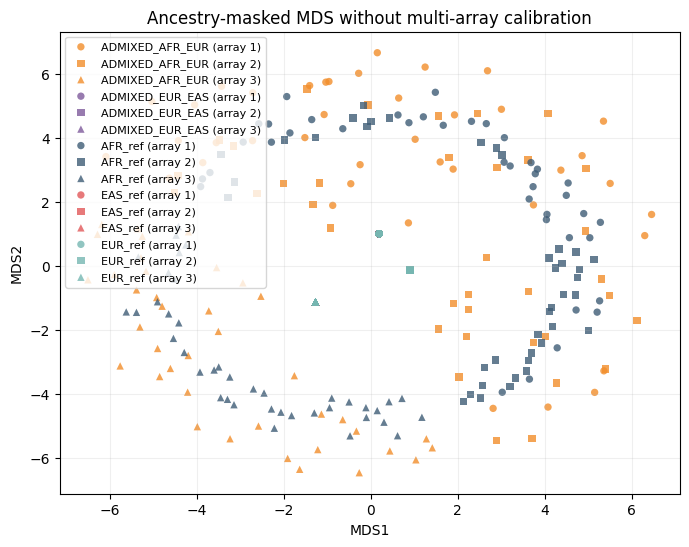

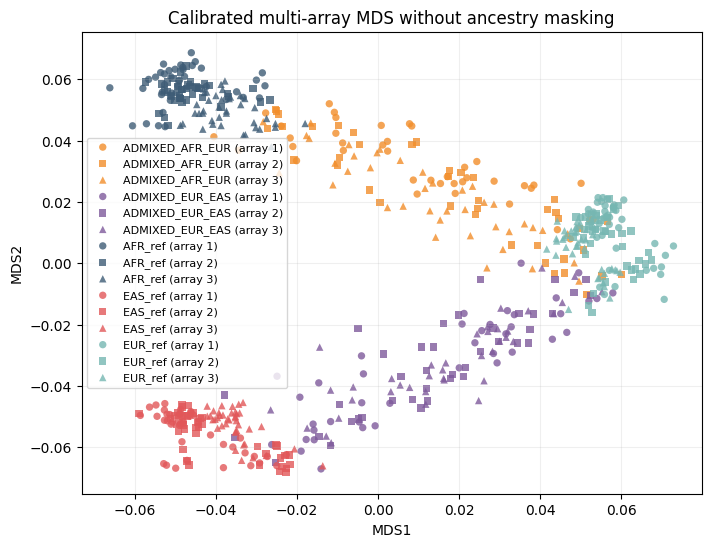

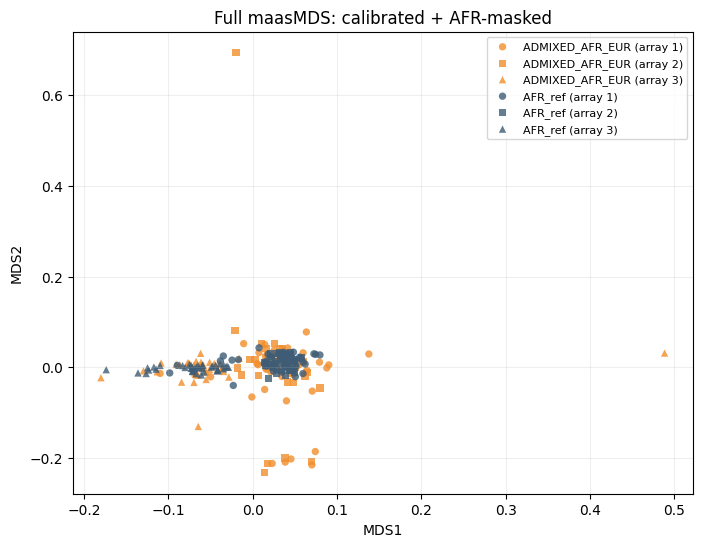

In [5]:
plot_population_by_array(
    uncalibrated_df,
    x="MDS1",
    y="MDS2",
    title="Ancestry-masked MDS without multi-array calibration",
)
plt.show()

plot_population_by_array(
    calibrated_no_mask_df,
    x="MDS1",
    y="MDS2",
    title="Calibrated multi-array MDS without ancestry masking",
)
plt.show()

plot_population_by_array(
    calibrated_df,
    x="MDS1",
    y="MDS2",
    title="Full maasMDS: calibrated + AFR-masked",
)
plt.show()
